# BÀI TẬP PHẦN 2: KHÁM PHÁ MÊ CUNG (MAZE EXPLORATION)

**Họ tên:** Nguyễn Ngọc Hải

**MSSV:** 24880218

## Hướng dẫn
Trong phần này, bạn sẽ cài đặt các thuật toán tìm kiếm (BFS, DFS, Greedy, UCS, A*) để tìm đường đi trong mê cung 2D.

**Quy định Tie-Break:**
Trong trường hợp các ô có cùng độ ưu tiên, chọn ô có **tọa độ `(r, c)` nhỏ hơn** (theo thứ tự từ điển: hàng nhỏ hơn, nếu hàng bằng thì cột nhỏ hơn).

**Input:** File text mô tả mê cung (`S`: Start, `E`: End, `#`: Tường).

**Lưu ý:**
- Bạn cần có file `maze.txt` nằm cùng thư mục với notebook này để chạy code.
- Các cell kiểm tra (Judge Cells) và Benchmarking sẽ **đọc trực tiếp dữ liệu từ file `maze.txt`** bằng hàm `read_maze` của bạn.

In [169]:
import time
import heapq
import random
import os
import matplotlib.pyplot as plt
from collections import deque
%matplotlib inline

### 2.1. Đọc dữ liệu mê cung

Viết hàm đọc file và trả về lưới (grid) cùng toạ độ Start/End.

In [170]:
def read_maze(filename):
    """
    Đọc mê cung từ file text.
    Trả về: (grid, start, end)
    """
    # YOUR CODE HERE
    grid = []
    start, end = None, None

    # Mở file
    with open(filename, "r", encoding="utf-8-sig") as f:
        # Duyệt qua các line trong file
        for line in f:
            # Cắt bỏ ký tự xuống dòng
            line = line.rstrip("\n")
            # Kiểm tra nếu line trống thì bỏ qua (thường là các dòng empty cuối file)
            if not line:
                continue
            # Nếu line chứa S (start)
            if "S" in line:
                start = (len(grid), line.index("S"))  # Set toạ độ (r, c) cho start
            # Nếu line chứa E (End)
            if "E" in line:
                end = (len(grid), line.index("E"))  # Set toạ độ (r, c) cho end
            # Cập nhật grid
            grid.append(list(line))

    return grid, start, end

grid, start, end = read_maze("maze.txt")

### 2.2. Các hàm bổ trợ (Heuristic & Neighbor)

**Yêu cầu:** Hàm `get_neighbors` phải trả về danh sách các ô kề **đã sắp xếp tăng dần theo tọa độ (row, col)** để đảm bảo tính nhất quán (tie-break) cho các thuật toán.

In [171]:
def manhattan_distance(a, b):
    # YOUR CODE HERE
    """Hàm trả về heuristic từ điểm a đến điểm b"""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def get_neighbors(grid, pos):
    # YOUR CODE HERE
    """Hàm trả về danh sách các ô kề đã sắp xếp tăng dần theo toạ độ (row, col)"""
    # Lấy vị trí (r, c) của pos
    row, col = pos
    # Tạo list vị trí kề theo ưu tiên (Tie-break): up, left, right, down
    adjacents = [(row - 1, col), (row, col - 1), (row, col + 1), (row + 1, col)]

    # Return list các ô kề đã sắp xếp
    return [(r, c) for r, c in adjacents
            if 0 <= r < len(grid) and 0 <= c < len(grid[r])  # Kiểm tra row và col hợp lệ
            and grid[r][c] != '#']                           # Kiểm tra position không phải là #

### 2.3. Cài đặt BFS cho Mê cung

Sử dụng `deque`.

In [172]:
def maze_bfs(grid, start, end):
    """
    Trả về list chứa đường đi từ start đến end.
    """
    # YOUR CODE HERE
    # Nếu start cũng là end
    if start == end: return [start]

    queue = deque([start])  # Queue dùng cho BFS
    trace = {start: None}   # Dict dùng để truy vết ngược đường đi từ start -> end

    def get_path():
        """Hàm trả về path từ start đến end"""
        path = [end]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Queue empty
    while queue:
        # Lấy node đầu Queue - FIFO
        current_pos = queue.popleft()
        # Duyệt qua các ô kề từ ô đang xét
        for next_pos in get_neighbors(grid, current_pos):
            # Bỏ qua nếu đã xét ô này
            if next_pos in trace:
                continue
            # Đánh dấu ô đã được xét
            trace[next_pos] = current_pos
            # Trả về path khi tìm thấy End
            if next_pos == end:
                return get_path()
            # Thêm các ô đi được vào Queue
            queue.append(next_pos)

    # Không tìm thấy đường đi -> Trả về None
    return None

In [173]:
# TEST CELL: Maze BFS (20 points)
print(maze_bfs(grid, start, end))

[(37, 33), (36, 33), (35, 33), (34, 33), (33, 33), (32, 33), (31, 33), (31, 34), (31, 35), (32, 35), (33, 35), (33, 36), (33, 37), (33, 38), (33, 39), (33, 40), (33, 41), (32, 41), (31, 41), (30, 41), (29, 41), (28, 41), (27, 41), (27, 40), (27, 39), (27, 38), (27, 37), (28, 37), (29, 37), (29, 36), (29, 35), (28, 35), (27, 35), (26, 35), (25, 35), (24, 35), (23, 35), (23, 36), (23, 37), (22, 37), (21, 37), (21, 38), (21, 39), (21, 40), (21, 41), (20, 41), (19, 41), (19, 42), (19, 43), (19, 44), (19, 45), (20, 45), (21, 45), (22, 45), (23, 45), (23, 44), (23, 43), (23, 42), (23, 41), (23, 40), (23, 39), (24, 39), (25, 39), (25, 40), (25, 41), (25, 42), (25, 43), (26, 43), (27, 43), (27, 44), (27, 45), (28, 45), (29, 45), (30, 45), (31, 45), (31, 44), (31, 43), (32, 43), (33, 43), (34, 43), (35, 43), (36, 43), (37, 43), (37, 44), (37, 45), (38, 45), (39, 45), (39, 46), (39, 47), (38, 47), (37, 47), (37, 48), (37, 49), (36, 49), (35, 49), (35, 48), (35, 47), (35, 46), (35, 45), (34, 45),

### 2.4. Cài đặt DFS cho Mê cung

Sử dụng `stack` (List). Để duyệt các ô lân cận theo thứ tự nhỏ trước (tie-break), bạn cần push chúng vào stack theo thứ tự ngược lại.

In [174]:
def maze_dfs(grid, start, end):
    """
    Trả về list chứa đường đi DFS.
    """
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là end
    if start == end: return [start]

    stack = [start]        # Stack của DFS
    visited = set()        # Set đánh dấu các ô đã duyệt
    trace = {start: None}  # Trace dict để truy vết ngược tìm path

    def get_path():
        """Hàm trả về path từ start đến end"""
        path = [end]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]
    
    # Loop đến khi stack empty
    while stack:
        current_pos = stack.pop()   # Pop position cần duyệt ra khỏi stack
        if current_pos in visited:  # Bỏ qua nếu position đã duyệt
            continue
        if current_pos == end:      # Trả về path nếu tìm thấy end
            return get_path()
        visited.add(current_pos)    # Đánh dấu đã duyệt

        # Mở rộng từ current position đang xét
        for next_pos in get_neighbors(grid, current_pos)[::-1]:
            if next_pos not in visited:        # Push nếu position chưa duyệt
                trace[next_pos] = current_pos  # Cập nhật previous position
                stack.append(next_pos)

    # Không tìm thấy path -> Trả về None
    return None

In [175]:
# TEST CELL: Maze DFS (20 points)
print(maze_dfs(grid, start, end))

[(37, 33), (36, 33), (35, 33), (34, 33), (33, 33), (32, 33), (31, 33), (31, 34), (31, 35), (32, 35), (33, 35), (33, 36), (33, 37), (33, 38), (33, 39), (33, 40), (33, 41), (32, 41), (31, 41), (30, 41), (29, 41), (28, 41), (27, 41), (27, 40), (27, 39), (27, 38), (27, 37), (28, 37), (29, 37), (29, 36), (29, 35), (28, 35), (27, 35), (26, 35), (25, 35), (24, 35), (23, 35), (23, 36), (23, 37), (22, 37), (21, 37), (21, 38), (21, 39), (21, 40), (21, 41), (20, 41), (19, 41), (19, 42), (19, 43), (19, 44), (19, 45), (20, 45), (21, 45), (22, 45), (23, 45), (23, 44), (23, 43), (23, 42), (23, 41), (23, 40), (23, 39), (24, 39), (25, 39), (25, 40), (25, 41), (25, 42), (25, 43), (26, 43), (27, 43), (27, 44), (27, 45), (28, 45), (29, 45), (30, 45), (31, 45), (31, 44), (31, 43), (32, 43), (33, 43), (34, 43), (35, 43), (36, 43), (37, 43), (37, 44), (37, 45), (38, 45), (39, 45), (39, 46), (39, 47), (38, 47), (37, 47), (37, 48), (37, 49), (36, 49), (35, 49), (35, 48), (35, 47), (35, 46), (35, 45), (34, 45),

### 2.5. Cài đặt Greedy Best-First Search cho Mê cung

Sử dụng `heapq` và heuristic Manhattan.

In [176]:
def maze_greedy_best_first(grid, start, end):
    """
    Greedy Best-First Search.
    """
    # YOUR CODE HERE
    # Nếu start cũng là end
    if start == end: return [start]

    queue = [(manhattan_distance(start, end), start)]  # Queue theo cấu trúc (heuristic, (r, c))
    trace = {start: None}

    def get_path():
        """Hàm trả về path từ start đến end"""
        path = [end]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Queue empty
    while queue:
        _, current_pos = heapq.heappop(queue)  # Dequeue position có heuristic nhỏ nhất khỏi queue

        # Mở rộng queue từ current position
        for next_pos in get_neighbors(grid, current_pos):
            # Bỏ qua nếu position đã duyệt
            if next_pos not in trace:
                trace[next_pos] = current_pos  # Cập nhật previous position
                if next_pos == end: return get_path()  # Nhìn thấy end, trả về path
                heapq.heappush(queue, (manhattan_distance(next_pos, end), next_pos))  # heuristic nhỏ sẽ được heapq xếp lên đầu queue

    # Không tìm thấy path -> Trả về None
    return None

In [177]:
# TEST CELL: Maze Greedy (20 points)
print(maze_greedy_best_first(grid, start, end))

[(37, 33), (36, 33), (35, 33), (34, 33), (33, 33), (32, 33), (31, 33), (31, 34), (31, 35), (32, 35), (33, 35), (33, 36), (33, 37), (33, 38), (33, 39), (33, 40), (33, 41), (32, 41), (31, 41), (30, 41), (29, 41), (28, 41), (27, 41), (27, 40), (27, 39), (27, 38), (27, 37), (28, 37), (29, 37), (29, 36), (29, 35), (28, 35), (27, 35), (26, 35), (25, 35), (24, 35), (23, 35), (23, 36), (23, 37), (22, 37), (21, 37), (21, 38), (21, 39), (21, 40), (21, 41), (20, 41), (19, 41), (19, 42), (19, 43), (19, 44), (19, 45), (20, 45), (21, 45), (22, 45), (23, 45), (23, 44), (23, 43), (23, 42), (23, 41), (23, 40), (23, 39), (24, 39), (25, 39), (25, 40), (25, 41), (25, 42), (25, 43), (26, 43), (27, 43), (27, 44), (27, 45), (28, 45), (29, 45), (30, 45), (31, 45), (31, 44), (31, 43), (32, 43), (33, 43), (34, 43), (35, 43), (36, 43), (37, 43), (37, 44), (37, 45), (38, 45), (39, 45), (39, 46), (39, 47), (38, 47), (37, 47), (37, 48), (37, 49), (36, 49), (35, 49), (35, 48), (35, 47), (35, 46), (35, 45), (34, 45),

### 2.6. Cài đặt Uniform Cost Search (UCS) cho Mê cung

Sử dụng `heapq`.

In [178]:
def maze_ucs(grid, start, end):
    """
    UCS Algorithm.
    """
    # YOUR CODE HERE
    # Nếu start cũng là end
    if start == end: return [start]

    queue = [(0, start)]   # Queue của UCS
    trace = {start: None}  # Trace dict để truy vết ngược khi tìm path
    cost = {start: 0}      # Cost dict lưu thông tin trọng số tốt nhất của position tương ứng

    def get_path():
        """Hàm trả về path từ start đến end"""
        path = [end]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Queue empty
    while queue:
        # Lấy trọng số và position có trọng số nhỏ nhất trong queue
        g, current_pos = heapq.heappop(queue)
        # Bỏ qua nếu position cũ
        if g > cost[current_pos]:
            continue

        # Trả về path nếu tìm thấy end
        if current_pos == end:
            return get_path()

        # Mở rộng queue từ current position
        for next_pos in get_neighbors(grid, current_pos):
            # Bỏ qua nếu position không có trọng số tốt hơn
            if g + 1 < cost.get(next_pos, float("inf")):
                cost[next_pos] = g + 1         # Cập nhật trọng số mới cho next position
                trace[next_pos] = current_pos  # Cập nhật previous position
                heapq.heappush(queue, (g + 1, next_pos))  # Enqueue ưu tiên theo trọng số

    # Không tìm thấy path -> Trả về None
    return None

In [179]:
# TEST CELL: Maze UCS (20 points)
print(maze_ucs(grid, start, end))

[(37, 33), (36, 33), (35, 33), (34, 33), (33, 33), (32, 33), (31, 33), (31, 34), (31, 35), (32, 35), (33, 35), (33, 36), (33, 37), (33, 38), (33, 39), (33, 40), (33, 41), (32, 41), (31, 41), (30, 41), (29, 41), (28, 41), (27, 41), (27, 40), (27, 39), (27, 38), (27, 37), (28, 37), (29, 37), (29, 36), (29, 35), (28, 35), (27, 35), (26, 35), (25, 35), (24, 35), (23, 35), (23, 36), (23, 37), (22, 37), (21, 37), (21, 38), (21, 39), (21, 40), (21, 41), (20, 41), (19, 41), (19, 42), (19, 43), (19, 44), (19, 45), (20, 45), (21, 45), (22, 45), (23, 45), (23, 44), (23, 43), (23, 42), (23, 41), (23, 40), (23, 39), (24, 39), (25, 39), (25, 40), (25, 41), (25, 42), (25, 43), (26, 43), (27, 43), (27, 44), (27, 45), (28, 45), (29, 45), (30, 45), (31, 45), (31, 44), (31, 43), (32, 43), (33, 43), (34, 43), (35, 43), (36, 43), (37, 43), (37, 44), (37, 45), (38, 45), (39, 45), (39, 46), (39, 47), (38, 47), (37, 47), (37, 48), (37, 49), (36, 49), (35, 49), (35, 48), (35, 47), (35, 46), (35, 45), (34, 45),

### 2.7. Cài đặt A* cho Mê cung

Sử dụng `heapq`. $f(n) = g(n) + h(n)$.

In [180]:
def maze_astar(grid, start, end):
    """
    A* Algorithm.
    """
    # YOUR CODE HERE
    # Nếu start cũng là end
    if start == end: return [start]

    queue = [(manhattan_distance(start, end), start)]  # Queue của A*
    trace = {start: None}                              # Trace dict để truy vết ngược tìm path
    cost  = {start: manhattan_distance(start, end)}    # Cost dict lưu thông tin f tốt nhất của position

    def get_path():
        """Hàm trả về path từ start đến end"""
        path = [end]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Queue empty
    while queue:
        f, current_pos = heapq.heappop(queue)  # Dequeue f và position có f tốt nhất khỏi Queue
        # Bỏ qua nếu position lưu f cũ
        if f > cost[current_pos]:
            continue
        # Tính trọng số g
        g = f - manhattan_distance(current_pos, end)

        # Trả về path nếu tìm thấy end
        if current_pos == end:
            return get_path()

        # Mở rộng queue từ position hiện tại
        for next_pos in get_neighbors(grid, current_pos):
            new_f = g + 1 + manhattan_distance(next_pos, end)  # Tính cost f của next position
            # Cập nhật nếu f tốt hơn f trước đó
            if new_f < cost.get(next_pos, float("inf")):
                trace[next_pos] = current_pos             # Cập nhật previous position
                cost[next_pos] = new_f                    # Lưu thông tin f của next position
                heapq.heappush(queue, (new_f, next_pos))  # Enqueue (f, (r, c)) vào queue

    # Không tìm thấy path -> Trả về None
    return None

In [181]:
# TEST CELL: Maze A* (20 points)
print(maze_astar(grid, start, end))

[(37, 33), (36, 33), (35, 33), (34, 33), (33, 33), (32, 33), (31, 33), (31, 34), (31, 35), (32, 35), (33, 35), (33, 36), (33, 37), (33, 38), (33, 39), (33, 40), (33, 41), (32, 41), (31, 41), (30, 41), (29, 41), (28, 41), (27, 41), (27, 40), (27, 39), (27, 38), (27, 37), (28, 37), (29, 37), (29, 36), (29, 35), (28, 35), (27, 35), (26, 35), (25, 35), (24, 35), (23, 35), (23, 36), (23, 37), (22, 37), (21, 37), (21, 38), (21, 39), (21, 40), (21, 41), (20, 41), (19, 41), (19, 42), (19, 43), (19, 44), (19, 45), (20, 45), (21, 45), (22, 45), (23, 45), (23, 44), (23, 43), (23, 42), (23, 41), (23, 40), (23, 39), (24, 39), (25, 39), (25, 40), (25, 41), (25, 42), (25, 43), (26, 43), (27, 43), (27, 44), (27, 45), (28, 45), (29, 45), (30, 45), (31, 45), (31, 44), (31, 43), (32, 43), (33, 43), (34, 43), (35, 43), (36, 43), (37, 43), (37, 44), (37, 45), (38, 45), (39, 45), (39, 46), (39, 47), (38, 47), (37, 47), (37, 48), (37, 49), (36, 49), (35, 49), (35, 48), (35, 47), (35, 46), (35, 45), (34, 45),

### 2.8. So sánh hiệu năng (Benchmarking)

Chạy tất cả các thuật toán trên cùng một mê cung để so sánh thời gian và độ dài đường đi. **Lưu ý:** Bạn cần có file `./maze.txt` trong cùng thư mục.

Algorithm  | Time (s)     | Path Length 
----------------------------------------
BFS        | 0.000757     | 127         
DFS        | 0.000180     | 127         
Greedy     | 0.000321     | 127         
UCS        | 0.001179     | 127         
A*         | 0.000931     | 127         


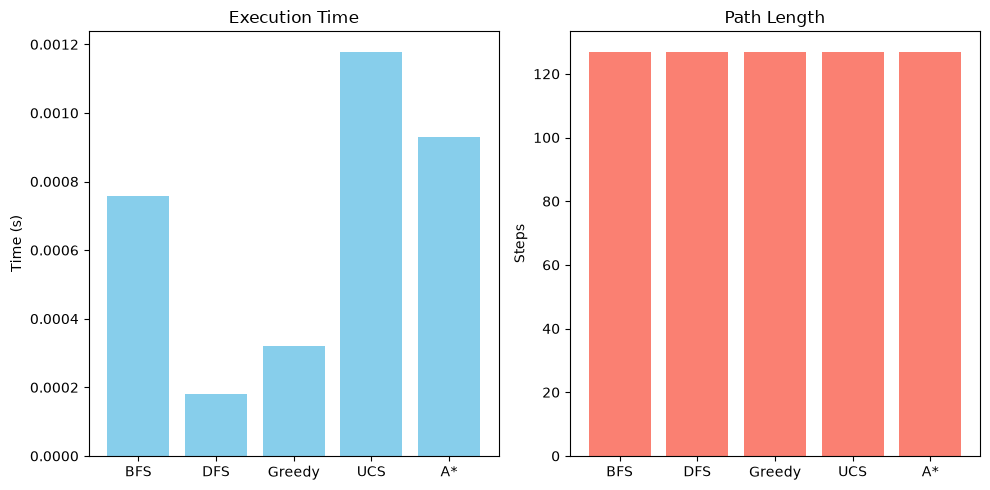

In [182]:
def benchmark_maze():
    try:
        grid, start, end = read_maze('./maze.txt')
    except FileNotFoundError:
        print("Lỗi: Không tìm thấy file './maze.txt'. Vui lòng tạo file này để chạy benchmark.")
        return

    # List of tuples: (Algorithm Name, Function Object)
    algos = [
        ("BFS", maze_bfs),
        ("DFS", maze_dfs),
        ("Greedy", maze_greedy_best_first),
        ("UCS", maze_ucs),
        ("A*", maze_astar)
    ]
    
    names = []
    times = []
    lengths = []
    
    print(f"{'Algorithm':<10} | {'Time (s)':<12} | {'Path Length':<12}")
    print("-"*40)
    
    for name, func in algos:
        start_time = time.time()
        try:
            path = func(grid, start, end)
            duration = time.time() - start_time
            length = len(path) if path else 0
        except NotImplementedError:
            duration = 0
            length = 0
            print(f"{name:<10} | Not Implemented")
            continue
            
        names.append(name)
        times.append(duration)
        lengths.append(length)
        print(f"{name:<10} | {duration:.6f}     | {length:<12}")
        
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(names, times, color='skyblue')
    plt.ylabel('Time (s)')
    plt.title('Execution Time')
    
    plt.subplot(1, 2, 2)
    plt.bar(names, lengths, color='salmon')
    plt.ylabel('Steps')
    plt.title('Path Length')
    
    plt.tight_layout()
    plt.show()

benchmark_maze()